# 🌍 Climate Change: Global Surface Temperature Analysis

## 📌 Table of Contents
1. [Introduction & Environmental Objective](#1)
2. [Data Loading & Library Imports](#2)
3. [Data Inspection (Historical Scan)](#3)
4. [Data Cleaning (Time-Series Conversion)](#4)
5. [Exploratory Data Analysis (EDA)](#5)
    - 5.1 [Annual Temperature Trend (1750-2015)](#5.1)
    - 5.2 [Decadal Analysis: The Warming Acceleration](#5.2)
6. [Strategic Conclusion & Climate Insights](#6)
7. [Connection to Tableau Dashboard](#7)

# <a id="1"></a> 1. Introduction & Environmental Objective
Global warming is one of the most critical challenges of our time. This notebook analyzes over **250 years** of temperature data to visualize how the Earth's climate has shifted since the Industrial Revolution.

**The Objective:** To identify long-term warming trends and provide visual evidence of temperature acceleration in the last few decades.

# <a id="2"></a> 2. Data Loading & Library Imports
We will use **Pandas** for data manipulation and **Seaborn/Matplotlib** for initial trend visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Path check kar lena
path = '/kaggle/input/datasets/obaidhere/climate-change-global-temperature-trends/GlobalTemperatures.csv'
df = pd.read_csv(path)
print("Historical Climate Data Loaded!")

Historical Climate Data Loaded!


# <a id="3"></a> 3. Data Inspection (Historical Scan)
Let's look at the structure of the dataset and identify the range of dates we are working with.

In [2]:
print(f"Dataset Shape: {df.shape}")
display(df.head())
display(df.tail())
display(df.info())

Dataset Shape: (3192, 9)


,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN
3,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN,NaN,NaN
4,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN,NaN,NaN


,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
3187,2015-08-01,14.755,0.072,20.699,0.110,9.005,0.170,17.589,0.057
3188,2015-09-01,12.999,0.079,18.845,0.088,7.199,0.229,17.049,0.058
3189,2015-10-01,10.801,0.102,16.450,0.059,5.232,0.115,16.290,0.062
3190,2015-11-01,7.433,0.119,12.892,0.093,2.157,0.106,15.252,0.063
3191,2015-12-01,5.518,0.100,10.725,0.154,0.287,0.099,14.774,0.062


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3192 entries, 0 to 3191
Data columns (total 9 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   dt                                         3192 non-null   object 
 1   LandAverageTemperature                     3180 non-null   float64
 2   LandAverageTemperatureUncertainty          3180 non-null   float64
 3   LandMaxTemperature                         1992 non-null   float64
 4   LandMaxTemperatureUncertainty              1992 non-null   float64
 5   LandMinTemperature                         1992 non-null   float64
 6   LandMinTemperatureUncertainty              1992 non-null   float64
 7   LandAndOceanAverageTemperature             1992 non-null   float64
 8   LandAndOceanAverageTemperatureUncertainty  1992 non-null   float64
dtypes: float64(8), object(1)
memory usage: 224.6+ KB


None

# <a id="4"></a> 4. Data Cleaning (Time-Series Conversion)
For an accurate analysis, we must convert the 'dt' column to a datetime object and handle missing values in the average temperature column.

In [3]:
# Date format conversion
df['dt'] = pd.to_datetime(df['dt'])
df['year'] = df['dt'].dt.year

# Keeping only necessary columns
df = df[['dt', 'year', 'LandAverageTemperature']]

# Removing Nulls (Early years often have missing data)
df = df.dropna(subset=['LandAverageTemperature'])

print("Cleaning Complete: Missing values removed and years extracted.")

Cleaning Complete: Missing values removed and years extracted.


# <a id="5"></a> 5. Exploratory Data Analysis (EDA)
In this section, we move from raw data to visual patterns. We will analyze the data on two levels: Yearly Trends and Decadal Shifts.

## <a id="5.1"></a> 5.1 Annual Temperature Trend (1750-2015)
This line chart shows the yearly average temperature of the Earth's surface over two and a half centuries.

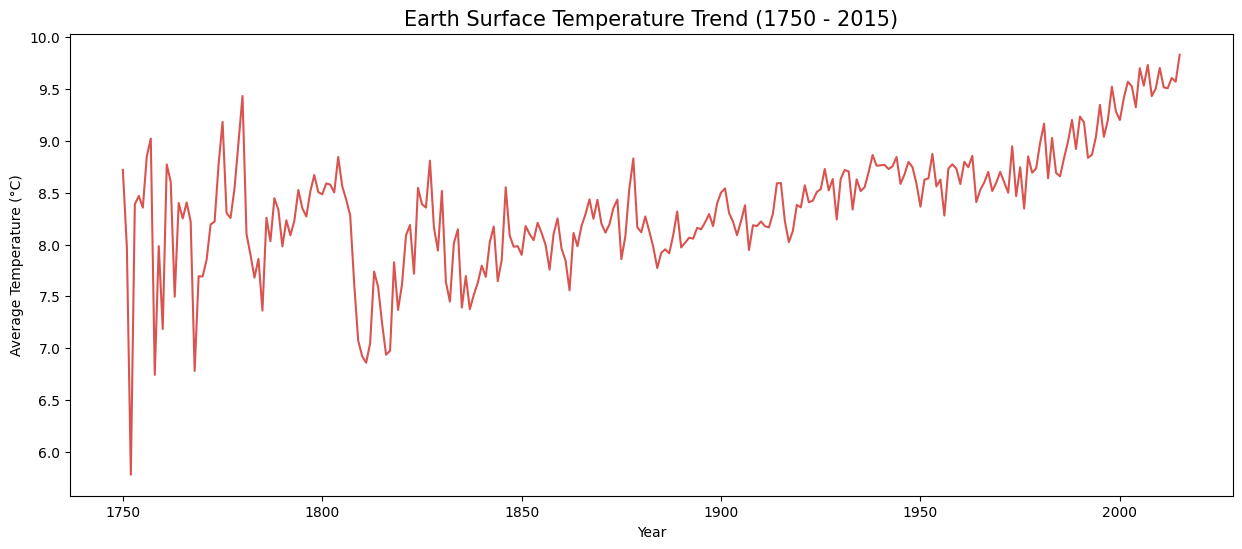

In [4]:
# Grouping by Year
annual_temp = df.groupby('year')['LandAverageTemperature'].mean().reset_index()

plt.figure(figsize=(15, 6))
sns.lineplot(x='year', y='LandAverageTemperature', data=annual_temp, color='#d9534f', linewidth=1.5)
plt.title('Earth Surface Temperature Trend (1750 - 2015)', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Average Temperature (°C)')
plt.show()

## <a id="5.2"></a> 5.2 Decadal Analysis: The Warming Acceleration
By grouping data into 10-year intervals (decades), we can clearly see the acceleration of global warming, filtering out minor yearly fluctuations.

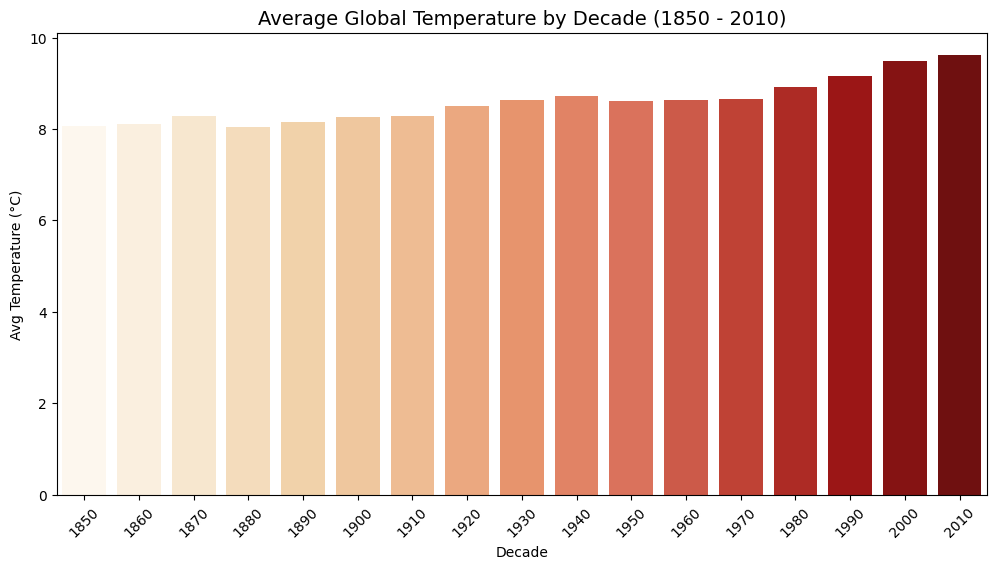

In [5]:
# Decade calculation
df['decade'] = (df['year'] // 10) * 10
decadal_avg = df.groupby('decade')['LandAverageTemperature'].mean().reset_index()

# Filtering for modern era (1850 onwards) for better comparison
decadal_avg = decadal_avg[decadal_avg['decade'] >= 1850]

plt.figure(figsize=(12, 6))
sns.barplot(x='decade', y='LandAverageTemperature', data=decadal_avg, palette='OrRd', hue='decade', legend=False)
plt.title('Average Global Temperature by Decade (1850 - 2010)', fontsize=14)
plt.xlabel('Decade')
plt.ylabel('Avg Temperature (°C)')
plt.xticks(rotation=45)
plt.show()

# <a id="6"></a> 6. Strategic Conclusion & Climate Insights
1. **Steady Increase:** The data provides undeniable evidence that the Earth's surface temperature has been rising steadily since the Industrial Revolution.
2. **Acceleration:** The bar chart in Section 5.2 highlights that the most significant temperature jumps occurred in the last four decades (1980-2010).
3. **Data Integrity:** While the 18th-century data shows some volatility, the 20th and 21st-century records are highly consistent, confirming the warming trend.

# <a id="7"></a> 7. Connection to Tableau Dashboard
These Python-based insights serve as the statistical engine for our **Tableau Time-Series Dashboard**. The interactive dashboard allows users to zoom into specific eras and visualize regional temperature anomalies beyond the global average.